In [1]:
import yt
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from mpl_toolkits.axes_grid1 import AxesGrid

In [2]:
# choose layout
fontsize  = 10

# setting of rows and columns in plots
nrows=1
ncols=1

# optionally setting the plot ranges
minrho=0.0
maxrho=2.0

# select the plots shown here (range/fields/title)
FixRange=[False]
minrange=[minrho]
maxrange=[maxrho]
fields=['rho']
titles=[r"$\rho$"]
cmapall=['Greys']

In [3]:
# select the data here
path_to_data = os.getcwd()+"/"
name_file="vaclogo"

# sleect frames begin/end
start =0
stop = 20


name_fig_file="fig"+name_file
movie_name="Movie"+name_file

Time_time=np.ones(stop-start+1,dtype=np.float64)
rhomin_time=np.ones(stop-start+1,dtype=np.float64)
rhomax_time=np.ones(stop-start+1,dtype=np.float64) 

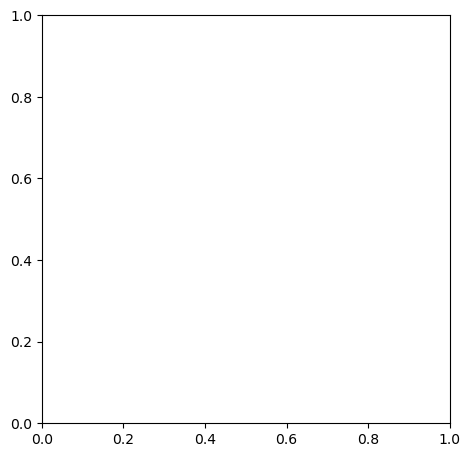

In [4]:
fig=plt.figure()
grid=AxesGrid(fig,(0.1,0.1,0.85,0.85),nrows_ncols=(nrows,ncols),share_all=True,axes_pad=0.2,cbar_mode=None)

def update(data,rhominframe,rhomaxframe):
    for i, (field_i,title_i,minrange_i,maxrange_i,cmap_i,FixRanges_i) in enumerate(zip(fields, titles,minrange,maxrange,cmapall,FixRange)):
        p=yt.plot_2d(data,field_i,origin='native')
        p.render()
        p.set_cmap(field_i,cmap=cmap_i)
        if FixRanges_i:
            p.set_zlim(field_i,minrange_i,maxrange_i)
        p.set_font_size(fontsize)
        p.annotate_title(title_i)
        p.annotate_timestamp()
        if field_i=='rho':
            p.annotate_text((0.1,0.8),'Minimum='+'{:.4f}'.format(rhominframe),coord_system="axis",text_args={"color":"blue"})
            p.annotate_text((0.1,0.9),'Maximum='+'{:.2f}'.format(rhomaxframe),coord_system="axis",text_args={"color":"blue"})
        if i==(nrows*ncols-1):
            p.annotate_grids()
        plot=p.plots[field_i]
        plot.axes=grid[i].axes
        plot.cax=grid.cbar_axes[i]
        p._setup_plots()
    return p

In [5]:
def animate(iframe):   
    name = path_to_data + name_file + str(iframe).zfill(4) + ".dat"
    yt.set_log_level(0)
    data = yt.load(name,unit_system='code')
    ad=data.all_data()
    time = round(float(data.current_time), 2)
    Time_time[iframe-start]=time
    rhomin_time[iframe-start]=ad['rho'].min()
    rhomax_time[iframe-start]=ad['rho'].max()
    update(data,rhomin_time[iframe-start],rhomax_time[iframe-start])
    return 

In [6]:
myAnimation = animation.FuncAnimation(fig, animate, frames=np.arange(start,stop+1,1), interval=100)
HTML(myAnimation.to_html5_video())

yt : [WARNING  ] 2026-09-24 11:43:08,631 e not found and no parfile passed, can not set thermal_pressure.
/Users/u0016541/yt/yt/visualization/base_plot_types.py:344: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 1031.52x889.443 with 2 Axes> which fig.colorbar is called on.
  self.cb = self.figure.colorbar(self.image, self.cax)


In [7]:
#myAnimation.save(path_to_data+movie_name+".mp4",fps=5)